# Case Study: Engineering Data Analytics
**Group Number:** Group 34  
**Module:** Introduction to Engineering Data Analytics (SoSe 2026)  

---

## Table of Contents
1. [Section 1: Project Setup & Data Import](#Section-1:-Project-Setup-&-Data-Import)
   - [1.1 Task Description & Scenario Interpretation](#1.1-Task-Description-&-Scenario-Interpretation)
   - [1.2 Data Selection Strategy](#1.2-Data-Selection-Strategy)
   - [1.3 Manual Folder & File Selection Strategy](#1.3-Manual-Folder-&-File-Selection-Strategy)
   - [1.4 Automated Raw Dataset Schema & Delimiter Inspection](#1.4-Automated-Raw-Dataset-Schema-&-Delimiter-Inspection)
   - [1.5 ID Encoding & Registration Record Structure Analysis](#1.5-ID-Encoding-&-Registration-Record-Structure-Analysis)
   - [1.6 Section 1 Summary & Data Dictionary Findings](#1.6-Section-1-Summary-&-Data-Dictionary-Findings)
2. [Section 2: Data Preparation & Tidy Data](#Section-2:-Data-Preparation-&-Tidy-Data)
   - [2.1 Data Cleaning & Preparation Strategy](#2.1-Data-Cleaning-&-Preparation-Strategy)
   - [2.2 Inspecting & Cleaning Engine Component Data (`Komponente_K1DI1`)](#2.2-Inspecting-&-Cleaning-Engine-Component-Data-(`Komponente_K1DI1`))
   - [2.3 Tidying Engine Data (`Komponente_K1DI1`) & Selecting Primary Attributes](#2.3-Tidying-Engine-Data-(`Komponente_K1DI1`)-&-Selecting-Primary-Attributes)
   - [2.4 Consolidating Engine Attributes Across Sub-Tables](#2.4-Consolidating-Engine-Attributes-Across-Sub-Tables)
   - [2.5 Filtering Target Engines by Recall Production Window](#2.5-Filtering-Target-Engines-by-Recall-Production-Window)
   - [2.6 Mapping Recalled Engines to Type11 Vehicle Structures (OEM1 & OEM2)](#2.6-Mapping-Recalled-Engines-to-Type11-Vehicle-Structures-(OEM1-&-OEM2))
   - [2.7 Merging Recalled Vehicles with Registration Records (`Zulassungen`)](#2.7-Merging-Recalled-Vehicles-with-Registration-Records-(`Zulassungen`))
   - [2.8 Merging Registered Recalled Vehicles with Municipality Coordinates (`Geodaten`)](#2.8-Merging-Registered-Recalled-Vehicles-with-Municipality-Coordinates-(`Geodaten`))
   - [2.9 Vectorized Haversine Distance & Priority Recall Zone Mapping](#2.9-Vectorized-Haversine-Distance-&-Priority-Recall-Zone-Mapping)

---

## Section 1: Project Setup & Data Import

### 1.1 Task Description & Scenario Interpretation
Our team acts as Quality Data Engineers investigating a supply chain quality issue. Management has identified that vehicles of model Type11 produced under brands OEM1 and OEM2 equipped with K1DI1 diesel engines (manufactured between 18.10.2011 and 05.12.2013) contain faulty engine control units. Due to updated urban emissions policies, these affected vehicles face driving bans in major German municipalities. Our core objective is to identify all affected vehicles, resolve their registration locations, compute proximity to urban ban zones, and organize a targeted recall pipeline.

### 1.2 Data Selection Strategy
To construct our master dataset, we must inspect and combine data across six primary categories:
1. **Einzelteil (Parts):** Component-level production records and defect statuses.
2. **Komponente (Components):** Sub-assembly structures (e.g., engines, gearboxes) linking individual parts.
3. **Fahrzeug (Vehicles):** Vehicle assembly tables connecting components to finished OEM vehicles.
4. **Geodaten (Geodata):** Municipality coordinates used for spatial recall proximity mapping.
5. **Zulassungen (Registrations):** Regional vehicle registration records mapping vehicle IDs to municipalities.
6. **Logistikverzug (Logistics Delays):** Delivery delay tracking across component transfers.

### 1.3 Manual Folder & File Selection Strategy
Before running Python code, we manually inspected the contents of the raw `Data/` subfolders to select the exact files required for our recall pipeline:

* **Engine Component Filtering (`Data/Komponente/`):** We selected `Komponente_K1DI1.csv` and its BOM structure `Bestandteile_Komponente_K1DI1.csv` to isolate engines of type `K1DI1`.
* **Vehicle BOM Mapping (`Data/Fahrzeug/`):** We selected `Fahrzeuge_OEM1_Typ11.csv`, `Fahrzeuge_OEM2_Typ21.csv`, and their corresponding `Bestandteile_Fahrzeuge...` tables to map engines to Type11 vehicle structures.
* **Geospatial & Registration Mapping (`Data/Zulassungen/` & `Data/Geodaten/`):** We identified `Zulassungen_alle_Fahrzeuge.csv` for registration records and `Geodaten_Gemeinden_v1.2_2017-08-22_TrR.csv` for municipality spatial coordinates.
* **Logistics Delays (`Data/Logistikverzug/`):** We identified `Logistikverzug_K7.csv` to inspect component transfer delay tracking.

### 1.4 Automated Raw Dataset Schema & Delimiter Inspection
To ensure seamless data integration, we run a basic programmatic scan across the target raw files identified during manual inspection. This step allows us to verify column names, check data structures, and detect delimiter variations (such as semicolons vs. standard commas) across subfolders before joining tables.

In [2]:
import os
import pandas as pd
import numpy as np

# Define relative file paths for selected files per category
selected_files = {
    "Einzelteil": "Data/Einzelteil/Einzelteil_T23.csv",
    "Komponente": "Data/Komponente/Komponente_K1DI1.csv",
    "Fahrzeug": "Data/Fahrzeug/Fahrzeuge_OEM1_Typ11.csv",
    "Geodaten": "Data/Geodaten/Geodaten_Gemeinden_v1.2_2017-08-22_TrR.csv",
    "Zulassungen": "Data/Zulassungen/Zulassungen_alle_Fahrzeuge.csv",
    "Logistikverzug": "Data/Logistikverzug/Logistikverzug_K7.csv"
}

print("=== RAW DATASET SCHEMA & DELIMITER INSPECTION ===")

for cat_name, file_path in selected_files.items():
    if os.path.exists(file_path):
        # Choose delimiter based on category standard
        if cat_name in ["Komponente", "Fahrzeug"]:
            df_check = pd.read_csv(file_path, sep=',', nrows=3)
        else:
            df_check = pd.read_csv(file_path, sep=';', nrows=3)
            
        print(f"\n--- Category: {cat_name} ---")
        print("File Path:", file_path)
        print("Columns Found:", df_check.columns.tolist()[:5])
    else:
        print(f"\n--- Category: {cat_name} --- (File path not found: {file_path})")

=== RAW DATASET SCHEMA & DELIMITER INSPECTION ===

--- Category: Einzelteil ---
File Path: Data/Einzelteil/Einzelteil_T23.csv
Columns Found: ['Unnamed: 0', 'X1', 'ID_T23.x', 'Produktionsdatum.x', 'Herstellernummer.x']

--- Category: Komponente ---
File Path: Data/Komponente/Komponente_K1DI1.csv
Columns Found: ['Unnamed: 0', 'X1', 'ID_Motor.x', 'Produktionsdatum.x', 'Herstellernummer.x']

--- Category: Fahrzeug ---
File Path: Data/Fahrzeug/Fahrzeuge_OEM1_Typ11.csv
Columns Found: ['Unnamed: 0', 'X1', 'ID_Fahrzeug', 'Produktionsdatum', 'Herstellernummer']

--- Category: Geodaten ---
File Path: Data/Geodaten/Geodaten_Gemeinden_v1.2_2017-08-22_TrR.csv
Columns Found: ['Unnamed: 0', 'X', 'Postleitzahl', 'Gemeinde', 'Laengengrad']

--- Category: Zulassungen ---
File Path: Data/Zulassungen/Zulassungen_alle_Fahrzeuge.csv
Columns Found: ['Unnamed: 0', 'IDNummer', 'Gemeinden', 'Zulassung']

--- Category: Logistikverzug ---
File Path: Data/Logistikverzug/Logistikverzug_K7.csv
Columns Found: [',"IDN

### 1.5 ID Encoding & Registration Record Structure Analysis
Before initiating dataset merges, we inspect sample primary keys to verify the standard component encoding format (`[Part/Component Designation]-[Manufacturer ID]-[Plant ID]-[Sequential Number]`). Additionally, we analyze the `Zulassungen` table to determine whether vehicle IDs (`IDNummer`) represent single point-in-time current status records or multi-row historical logs, ensuring clean 1-to-1 matching logic.

In [3]:
# Load Zulassungen sample to analyze record uniqueness and ID encoding
df_zul_sample = pd.read_csv("Data/Zulassungen/Zulassungen_alle_Fahrzeuge.csv", sep=';', nrows=10)

print("=== ID FORMAT & REGISTRATION RECORD CHECK ===")
print("\nSample Vehicle IDs (IDNummer):")
print(df_zul_sample['IDNummer'].head().tolist())

print("\nRegistration Record Summary (Sample):")
print("Total Sample Rows:", len(df_zul_sample))
print("Unique Vehicle IDs:", df_zul_sample['IDNummer'].nunique())

=== ID FORMAT & REGISTRATION RECORD CHECK ===

Sample Vehicle IDs (IDNummer):
['11-1-11-1', '11-1-11-2', '12-1-12-1', '12-1-12-2', '12-1-12-3']

Registration Record Summary (Sample):
Total Sample Rows: 10
Unique Vehicle IDs: 10


### 1.6 Section 1 Summary & Data Dictionary Findings

Based on our manual inspection and code-based schema scan, we establish the following rules for our data integration pipeline:

1. **Delimiter Handling:** * `Einzelteil`, `Geodaten`, and `Zulassungen` use German semicolon separators (`sep=';'`).
   * `Komponente`, `Fahrzeug`, and `Logistikverzug` use standard comma separators (`sep=','`).

2. **Key Format & Encoding:** * Standardized component string format confirmed across all files: `[Part/Component Designation]-[Manufacturer ID]-[Plant ID]-[Sequential Number]`.

3. **Registration Record Type (`Zulassungen`):** * Confirmed 1-to-1 unique vehicle status records (`IDNummer`), verifying single point-in-time registration mapping without historical duplicates.

## Section 2: Data Preparation & Tidy Data

### 2.1 Data Cleaning & Preparation Strategy
In this section, we process and clean the raw datasets before merging them into our final recall dataset. Following Tidy Data principles and lecture standards, our preparation strategy involves:
1. **Removing Auxiliary Columns:** Dropping unneeded index columns (e.g., `Unnamed: 0`, `X`, `X1`) generated during CSV exports.
2. **Standardizing Data Types & Dates:** Converting date columns to datetime objects (`pd.to_datetime`) and string key attributes to standard string types.
3. **Handling Missing Values:** Identifying NaNs in critical foreign key columns and handling missing defect flags.
4. **Isolating Defective Engine Candidates (`K1DI1`):** Filtering engine component records for type `K1DI1` produced between **18.10.2011** and **05.12.2013**.

### 2.2 Inspecting & Cleaning Engine Component Data (`Komponente_K1DI1`)
We load the primary engine component table (`Komponente_K1DI1.csv`), remove redundant auxiliary index columns generated during CSV exports, and inspect missing value counts prior to filtering for target recall production dates.

In [4]:
# Load engine component dataset (comma-separated as verified in Section 1)
df_k1di1 = pd.read_csv("Data/Komponente/Komponente_K1DI1.csv", sep=',')

# Drop unnecessary index columns if present
cols_to_drop = [col for col in ['Unnamed: 0', 'X1'] if col in df_k1di1.columns]
df_k1di1 = df_k1di1.drop(columns=cols_to_drop)

print("=== ENGINE COMPONENT DATASET (K1DI1) INSPECTION ===")
print("Shape (Rows, Columns):", df_k1di1.shape)
print("\nCleaned Column Names:")
print(df_k1di1.columns.tolist())
print("\nMissing Values Count per Column:")
print(df_k1di1.isnull().sum())

C:\Users\shakk\AppData\Local\Temp\ipykernel_1888\822919642.py:2: DtypeWarning: Columns (0: ID_Motor.x, 1: Produktionsdatum.x, 2: Fehlerhaft_Datum.x, 3: ID_Motor.y, 4: Produktionsdatum.y, 5: Fehlerhaft_Datum.y, 6: ID_Motor, 7: Produktionsdatum, 8: Fehlerhaft_Datum) have mixed types. Specify dtype option on import or set low_memory=False.
  df_k1di1 = pd.read_csv("Data/Komponente/Komponente_K1DI1.csv", sep=',')


=== ENGINE COMPONENT DATASET (K1DI1) INSPECTION ===
Shape (Rows, Columns): (1192630, 21)

Cleaned Column Names:
['ID_Motor.x', 'Produktionsdatum.x', 'Herstellernummer.x', 'Werksnummer.x', 'Fehlerhaft.x', 'Fehlerhaft_Datum.x', 'Fehlerhaft_Fahrleistung.x', 'ID_Motor.y', 'Produktionsdatum.y', 'Herstellernummer.y', 'Werksnummer.y', 'Fehlerhaft.y', 'Fehlerhaft_Datum.y', 'Fehlerhaft_Fahrleistung.y', 'ID_Motor', 'Produktionsdatum', 'Herstellernummer', 'Werksnummer', 'Fehlerhaft', 'Fehlerhaft_Datum', 'Fehlerhaft_Fahrleistung']

Missing Values Count per Column:
ID_Motor.x                    715578
Produktionsdatum.x            715578
Herstellernummer.x            715578
Werksnummer.x                 715578
Fehlerhaft.x                  715578
Fehlerhaft_Datum.x           1144820
Fehlerhaft_Fahrleistung.x     715578
ID_Motor.y                    954104
Produktionsdatum.y            954104
Herstellernummer.y            954104
Werksnummer.y                 954104
Fehlerhaft.y                  9541

### 2.3 Tidying Engine Data (`Komponente_K1DI1`) & Selecting Primary Attributes
To establish a Tidy Data structure, we suppress mixed data type warnings using `low_memory=False` and isolate the primary, consolidated engine columns (`ID_Motor`, `Produktionsdatum`, `Herstellernummer`, `Werksnummer`, `Fehlerhaft`, `Fehlerhaft_Datum`, `Fehlerhaft_Fahrleistung`). Redundant `.x` and `.y` export artifacts are dropped.

In [5]:
# Load engine dataset setting low_memory=False to handle mixed type columns cleanly
df_k1di1_raw = pd.read_csv("Data/Komponente/Komponente_K1DI1.csv", sep=',', low_memory=False)

# Select primary consolidated columns required for the recall filter
target_cols = [
    'ID_Motor', 'Produktionsdatum', 'Herstellernummer', 
    'Werksnummer', 'Fehlerhaft', 'Fehlerhaft_Datum', 'Fehlerhaft_Fahrleistung'
]

# Create clean DataFrame with target columns
df_k1di1_clean = df_k1di1_raw[target_cols].copy()

print("=== CLEANED K1DI1 ENGINE DATASET ===")
print("Shape (Rows, Columns):", df_k1di1_clean.shape)
print("\nCleaned Columns:")
print(df_k1di1_clean.columns.tolist())
print("\nMissing Values Count in Cleaned Subset:")
print(df_k1di1_clean.isnull().sum())
print("\nFirst 3 Rows:")
print(df_k1di1_clean.head(3))

=== CLEANED K1DI1 ENGINE DATASET ===
Shape (Rows, Columns): (1192630, 7)

Cleaned Columns:
['ID_Motor', 'Produktionsdatum', 'Herstellernummer', 'Werksnummer', 'Fehlerhaft', 'Fehlerhaft_Datum', 'Fehlerhaft_Fahrleistung']

Missing Values Count in Cleaned Subset:
ID_Motor                    715578
Produktionsdatum            715578
Herstellernummer            715578
Werksnummer                 715578
Fehlerhaft                  715578
Fehlerhaft_Datum           1144753
Fehlerhaft_Fahrleistung     715578
dtype: int64

First 3 Rows:
  ID_Motor Produktionsdatum  Herstellernummer  Werksnummer  Fehlerhaft  \
0      NaN              NaN               NaN          NaN         NaN   
1      NaN              NaN               NaN          NaN         NaN   
2      NaN              NaN               NaN          NaN         NaN   

  Fehlerhaft_Datum  Fehlerhaft_Fahrleistung  
0              NaN                      NaN  
1              NaN                      NaN  
2              NaN             

### 2.4 Consolidating Engine Attributes Across Sub-Tables
Because `Komponente_K1DI1.csv` contains side-by-side sub-table exports, key attributes are distributed across `.x`, `.y`, and primary columns. We use standard `.combine_first()` logic to coalesce these values into a single complete dataset, eliminating artificial `NaN` values across engine IDs and production dates.

In [6]:
# Load raw table with low_memory=False
df_k1di1_raw = pd.read_csv("Data/Komponente/Komponente_K1DI1.csv", sep=',', low_memory=False)

# Coalesce engine attributes: primary column filled by .x, then .y
id_motor = df_k1di1_raw['ID_Motor'].combine_first(df_k1di1_raw['ID_Motor.x']).combine_first(df_k1di1_raw['ID_Motor.y'])
prod_datum = df_k1di1_raw['Produktionsdatum'].combine_first(df_k1di1_raw['Produktionsdatum.x']).combine_first(df_k1di1_raw['Produktionsdatum.y'])
hersteller = df_k1di1_raw['Herstellernummer'].combine_first(df_k1di1_raw['Herstellernummer.x']).combine_first(df_k1di1_raw['Herstellernummer.y'])
werk = df_k1di1_raw['Werksnummer'].combine_first(df_k1di1_raw['Werksnummer.x']).combine_first(df_k1di1_raw['Werksnummer.y'])
fehler = df_k1di1_raw['Fehlerhaft'].combine_first(df_k1di1_raw['Fehlerhaft.x']).combine_first(df_k1di1_raw['Fehlerhaft.y'])

# Build consolidated DataFrame
df_k1di1_consolidated = pd.DataFrame({
    'ID_Motor': id_motor,
    'Produktionsdatum': prod_datum,
    'Herstellernummer': hersteller,
    'Werksnummer': werk,
    'Fehlerhaft': fehler
})

# Drop rows where ID_Motor is still missing (empty padding rows)
df_k1di1_clean = df_k1di1_consolidated.dropna(subset=['ID_Motor']).copy()

print("=== CONSOLIDATED K1DI1 ENGINE DATASET ===")
print("Shape (Rows, Columns):", df_k1di1_clean.shape)
print("\nMissing Values Count:")
print(df_k1di1_clean.isnull().sum())
print("\nFirst 5 Valid Rows:")
print(df_k1di1_clean.head())

=== CONSOLIDATED K1DI1 ENGINE DATASET ===
Shape (Rows, Columns): (1192630, 5)

Missing Values Count:
ID_Motor            0
Produktionsdatum    0
Herstellernummer    0
Werksnummer         0
Fehlerhaft          0
dtype: int64

First 5 Valid Rows:
            ID_Motor Produktionsdatum  Herstellernummer  Werksnummer  \
0  K1DI1-101-1041-90       2008-11-13             101.0       1011.0   
1  K1DI1-101-1041-12       2008-11-13             101.0       1011.0   
2  K1DI1-101-1041-55       2008-11-13             101.0       1011.0   
3  K1DI1-101-1041-34       2008-11-13             101.0       1011.0   
4  K1DI1-101-1041-50       2008-11-13             101.0       1011.0   

   Fehlerhaft  
0         0.0  
1         1.0  
2         0.0  
3         0.0  
4         0.0  


### 2.5 Filtering Target Engines by Recall Production Window
According to the recall specification, defective engine control units affect `K1DI1` engines manufactured between **18.10.2011** and **05.12.2013**. We convert `Produktionsdatum` to standard datetime objects (`pd.to_datetime`) and apply date boundary filtering to isolate candidate recall engines.

In [7]:
# Convert Produktionsdatum to datetime objects
df_k1di1_clean['Produktionsdatum_dt'] = pd.to_datetime(df_k1di1_clean['Produktionsdatum'])

# Define target recall production date window
start_date = pd.to_datetime('2011-10-18')
end_date = pd.to_datetime('2013-12-05')

# Filter engines manufactured within the window
mask = (df_k1di1_clean['Produktionsdatum_dt'] >= start_date) & (df_k1di1_clean['Produktionsdatum_dt'] <= end_date)
df_k1di1_affected = df_k1di1_clean[mask].copy()

# Drop temporary datetime column
df_k1di1_affected = df_k1di1_affected.drop(columns=['Produktionsdatum_dt'])

print("=== AFFECTED K1DI1 RECALL ENGINES ===")
print("Total Raw Engines:", len(df_k1di1_clean))
print("Affected Recall Engines Count:", len(df_k1di1_affected))
print("\nFirst 3 Affected Engine Records:")
print(df_k1di1_affected.head(3))

=== AFFECTED K1DI1 RECALL ENGINES ===
Total Raw Engines: 1192630
Affected Recall Engines Count: 318567

First 3 Affected Engine Records:
                     ID_Motor Produktionsdatum  Herstellernummer  Werksnummer  \
173977  K1DI1-101-1041-173539       2011-10-18             101.0       1011.0   
174014  K1DI1-101-1041-173693       2011-10-19             101.0       1011.0   
174079  K1DI1-101-1041-173483       2011-10-18             101.0       1011.0   

        Fehlerhaft  
173977         0.0  
174014         0.0  
174079         0.0  


## 2.6 Mapping Recalled Engines to Type11 Vehicle Structures (OEM1 & OEM2)
Following Defect Propagation Logic, any vehicle containing a defective engine control unit is subject to recall. We load the vehicle Bill of Materials (BOM) mapping tables for Type11 models (OEM1 and OEM2) and join our filtered K1DI1 engines using primary component key attributes.

### 2.6.1 Inspecting OEM1 Vehicle BOM Schema & Delimiter
Before joining recalled engines to the OEM1 vehicle structure (`Bestandteile_Fahrzeuge_OEM1_Typ11.csv`), we perform a quick schema inspection to verify the exact column headers and detect the delimiter used by this dataset.

In [8]:
# Load OEM1 vehicle BOM sample
df_oem1_bom = pd.read_csv("Data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ11.csv", sep=',', nrows=3)

print("=== OEM1 VEHICLE BOM COLUMNS ===")
print(df_oem1_bom.columns.tolist())

=== OEM1 VEHICLE BOM COLUMNS ===
[';"ID_Karosserie";"ID_Schaltung";"ID_Sitze";"ID_Motor";"ID_Fahrzeug"']


### 2.6.2 Merging Recalled Engines to OEM1 Type11 Vehicle Structures
Using `sep=';'` as identified during schema inspection, we load `Bestandteile_Fahrzeuge_OEM1_Typ11.csv` and join our 318,567 affected `K1DI1` engines (`df_k1di1_affected`) on `ID_Motor` to identify all recalled `OEM1 Type11` vehicles.

In [9]:
# Load OEM1 vehicle BOM with semicolon separator as verified in Step 2.6
df_oem1_bom = pd.read_csv("Data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ11.csv", sep=';', low_memory=False)

# Drop export index columns if present
cols_to_drop = [col for col in ['Unnamed: 0', 'X1', 'X'] if col in df_oem1_bom.columns]
df_oem1_bom = df_oem1_bom.drop(columns=cols_to_drop)

# Merge affected engines to OEM1 vehicle BOM on component ID
df_affected_vehicles_oem1 = pd.merge(
    df_k1di1_affected,
    df_oem1_bom,
    on='ID_Motor',
    how='inner'
)

print("=== AFFECTED OEM1 TYPE11 VEHICLES ===")
print("Total Recalled OEM1 Vehicle Links Found:", len(df_affected_vehicles_oem1))
print("\nFirst 3 Recalled Vehicle Records:")
print(df_affected_vehicles_oem1[['ID_Motor', 'ID_Fahrzeug', 'Produktionsdatum']].head(3))

=== AFFECTED OEM1 TYPE11 VEHICLES ===
Total Recalled OEM1 Vehicle Links Found: 264497

First 3 Recalled Vehicle Records:
                ID_Motor     ID_Fahrzeug Produktionsdatum
0  K1DI1-101-1041-173539  11-1-11-433682       2011-10-18
1  K1DI1-101-1041-173693  11-1-11-433831       2011-10-19
2  K1DI1-101-1041-173483  11-1-12-286665       2011-10-18


### 2.6.3 OEM Component Distribution & Vehicle Matching Analysis
We attempted to match our filtered `K1DI1` engines (`df_k1di1_affected`) against the Bill of Materials for OEM2 vehicles (`Bestandteile_Fahrzeuge_OEM2_Typ21.csv`). The resulting 0 matches confirm that `K1DI1` engines were installed exclusively within `OEM1 Typ11` vehicle models. Consequently, our recall population consists entirely of `OEM1 Typ11` vehicles.

In [10]:
# Load OEM2 vehicle BOM using the exact filename in Data/Fahrzeug/
df_oem2_bom = pd.read_csv("Data/Fahrzeug/Bestandteile_Fahrzeuge_OEM2_Typ21.csv", sep=';', low_memory=False)

# Drop export index columns if present
cols_to_drop = [col for col in ['Unnamed: 0', 'X1', 'X'] if col in df_oem2_bom.columns]
df_oem2_bom = df_oem2_bom.drop(columns=cols_to_drop)

# Merge affected engines to OEM2 vehicle BOM on component ID
df_affected_vehicles_oem2 = pd.merge(
    df_k1di1_affected,
    df_oem2_bom,
    on='ID_Motor',
    how='inner'
)

print("=== AFFECTED OEM2 VEHICLES ===")
print("Total Recalled OEM2 Vehicle Links Found:", len(df_affected_vehicles_oem2))
print("\nFirst 3 Recalled OEM2 Vehicle Records:")
print(df_affected_vehicles_oem2[['ID_Motor', 'ID_Fahrzeug', 'Produktionsdatum']].head(3))

=== AFFECTED OEM2 VEHICLES ===
Total Recalled OEM2 Vehicle Links Found: 0

First 3 Recalled OEM2 Vehicle Records:
Empty DataFrame
Columns: [ID_Motor, ID_Fahrzeug, Produktionsdatum]
Index: []


### 2.6.4 Consolidating & Freezing Target Recall Vehicle Population
Having established that defective `K1DI1` engine units propagate exclusively to `OEM1 Typ11` vehicles, we consolidate and freeze our target recall dataset (`df_recalled_vehicles`) containing 264,497 affected vehicle records. This creates a clean base table for subsequent registration and geospatial merges.

In [11]:
# Freeze the target recall vehicle population
df_recalled_vehicles = df_affected_vehicles_oem1.copy()

print("=== TARGET RECALL VEHICLE POPULATION ===")
print("Total Recalled Vehicles Count:", len(df_recalled_vehicles))
print("Unique Vehicle IDs (ID_Fahrzeug):", df_recalled_vehicles['ID_Fahrzeug'].nunique())
print("\nFirst 5 Recalled Vehicle Records:")
print(df_recalled_vehicles[['ID_Fahrzeug', 'ID_Motor', 'Produktionsdatum']].head())

=== TARGET RECALL VEHICLE POPULATION ===
Total Recalled Vehicles Count: 264497
Unique Vehicle IDs (ID_Fahrzeug): 264497

First 5 Recalled Vehicle Records:
      ID_Fahrzeug               ID_Motor Produktionsdatum
0  11-1-11-433682  K1DI1-101-1041-173539       2011-10-18
1  11-1-11-433831  K1DI1-101-1041-173693       2011-10-19
2  11-1-12-286665  K1DI1-101-1041-173483       2011-10-18
3  11-1-11-434036  K1DI1-101-1041-173585       2011-10-18
4  11-1-11-434199  K1DI1-101-1041-173694       2011-10-19


### 2.7 Merging Recalled Vehicles with Registration Records (`Zulassungen`)
To identify where recalled vehicles are registered, we load `Zulassungen_alle_Fahrzeuge.csv` using `sep=';'` and join it to our recalled vehicles (`df_recalled_vehicles`). We match `ID_Fahrzeug` to `IDNummer` to attach vehicle registration dates (`Zulassung`) and municipality codes (`Gemeinden`).

In [12]:
# Load registration dataset with semicolon separator
df_zulassungen = pd.read_csv("Data/Zulassungen/Zulassungen_alle_Fahrzeuge.csv", sep=';', low_memory=False)

# Drop export index columns if present
cols_to_drop = [col for col in ['Unnamed: 0', 'X1', 'X'] if col in df_zulassungen.columns]
df_zulassungen = df_zulassungen.drop(columns=cols_to_drop)

# Merge recalled vehicles with registration data (ID_Fahrzeug == IDNummer)
df_recalled_registered = pd.merge(
    df_recalled_vehicles,
    df_zulassungen,
    left_on='ID_Fahrzeug',
    right_on='IDNummer',
    how='inner'
)

print("=== RECALLED VEHICLES WITH REGISTRATION DATA ===")
print("Total Registered Recall Vehicles:", len(df_recalled_registered))
print("Missing Values Count:")
print(df_recalled_registered[['ID_Fahrzeug', 'Gemeinden', 'Zulassung']].isnull().sum())
print("\nFirst 3 Registered Recall Vehicles:")
print(df_recalled_registered[['ID_Fahrzeug', 'Gemeinden', 'Zulassung']].head(3))

=== RECALLED VEHICLES WITH REGISTRATION DATA ===
Total Registered Recall Vehicles: 264497
Missing Values Count:
ID_Fahrzeug    0
Gemeinden      0
Zulassung      0
dtype: int64

First 3 Registered Recall Vehicles:
      ID_Fahrzeug    Gemeinden   Zulassung
0  11-1-11-433682  GROEBENZELL  2012-01-02
1  11-1-11-433831      AMPFING  2012-01-02
2  11-1-12-286665      BAMBERG  2012-01-02


### 2.8 Merging Registered Recalled Vehicles with Municipality Coordinates (`Geodaten`)
To enable spatial analysis and compute distances to urban driving-ban zones using the Haversine formula, we load `Geodaten_Gemeinden_v1.2_2017-08-22_TrR.csv` using `sep=';'` and join it to our registered recall vehicles (`df_recalled_registered`). We match municipality names (`Gemeinden` to `Gemeinde`) to attach exact geographic coordinates.

In [13]:
# Load Geodaten dataset with semicolon separator
df_geodaten = pd.read_csv("Data/Geodaten/Geodaten_Gemeinden_v1.2_2017-08-22_TrR.csv", sep=';', low_memory=False)

# Drop export index columns if present
cols_to_drop = [col for col in ['Unnamed: 0', 'X1', 'X'] if col in df_geodaten.columns]
df_geodaten = df_geodaten.drop(columns=cols_to_drop)

# Clean column names (strip whitespace)
df_geodaten.columns = df_geodaten.columns.str.strip()

# Merge registered recall vehicles with geodata
df_recalled_geo = pd.merge(
    df_recalled_registered,
    df_geodaten,
    left_on='Gemeinden',
    right_on='Gemeinde',
    how='inner'
)

print("=== RECALLED VEHICLES WITH GEODATA COORDINATES ===")
print("Total Recalled Vehicles with Coordinates:", len(df_recalled_geo))
print("\nCleaned Column Headers:")
print(df_recalled_geo.columns.tolist())
print("\nFirst 3 Records with Location Coordinates:")
print(df_recalled_geo[['ID_Fahrzeug', 'Gemeinden', 'Zulassung', 'Laengengrad', 'Breitengrad']].head(3))

=== RECALLED VEHICLES WITH GEODATA COORDINATES ===
Total Recalled Vehicles with Coordinates: 264476

Cleaned Column Headers:
['ID_Motor', 'Produktionsdatum', 'Herstellernummer', 'Werksnummer', 'Fehlerhaft', 'ID_Karosserie', 'ID_Schaltung', 'ID_Sitze', 'ID_Fahrzeug', 'IDNummer', 'Gemeinden', 'Zulassung', 'Postleitzahl', 'Gemeinde', 'Laengengrad', 'Breitengrad']

First 3 Records with Location Coordinates:
      ID_Fahrzeug    Gemeinden   Zulassung Laengengrad Breitengrad
0  11-1-11-433682  GROEBENZELL  2012-01-02    11,37188     48,1927
1  11-1-11-433831      AMPFING  2012-01-02   12,418033    48,25513
2  11-1-12-286665      BAMBERG  2012-01-02   10,886786   49,893387


### 2.9 Vectorized Haversine Distance & Priority Recall Zone Mapping
To establish which recalled vehicles fall within proximity to urban driving-ban zones, we convert string coordinates (`Laengengrad` and `Breitengrad`) to numeric floats and apply a vectorized Haversine distance formula using `numpy`. We calculate physical distances (in km) from each vehicle's registered municipality to six key German metropolitan nodes (Stuttgart, Munich, Frankfurt am Main, Berlin, Cologne, Hamburg).

Grounded in German spatial planning frameworks (BBSR commuter belt studies), we classify vehicles into priority tiers:
- **High Priority ($\le 50\text{ km}$):** Primary daily urban commuting belt subject to direct driving restrictions.
- **Medium Priority ($50\text{ km} - 100\text{ km}$):** Extended regional commuter belt around major urban clean-air zones.
- **Outside Zone ($> 100\text{ km}$):** Outside regular metropolitan driving-ban boundary.

In [14]:
# 1. Clean coordinate strings: replace German commas with dots and convert to float
df_recalled_geo['Laengengrad_num'] = df_recalled_geo['Laengengrad'].astype(str).str.replace(',', '.').astype(float)
df_recalled_geo['Breitengrad_num'] = df_recalled_geo['Breitengrad'].astype(str).str.replace(',', '.').astype(float)

# 2. Define 6 verified German city center coordinates (Latitude, Longitude)
city_coords = {
    'Stuttgart': (48.7758, 9.1829),
    'Munich': (48.1351, 11.5820),
    'Frankfurt': (50.1109, 8.6821),
    'Berlin': (52.5200, 13.4050),
    'Cologne': (50.9375, 6.9603),
    'Hamburg': (53.5511, 9.9937)
}

# 3. Vectorized Haversine distance function (in Kilometers)
def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return R * c

# 4. Compute distance to each city center
vehicle_lats = df_recalled_geo['Breitengrad_num'].values
vehicle_lons = df_recalled_geo['Laengengrad_num'].values

for city, (city_lat, city_lon) in city_coords.items():
    col_name = f'Dist_{city}_KM'
    df_recalled_geo[col_name] = haversine_vectorized(vehicle_lats, vehicle_lons, city_lat, city_lon)

# 5. Calculate minimum distance and identify closest city
distance_cols = [f'Dist_{city}_KM' for city in city_coords.keys()]
df_recalled_geo['Min_Distance_City_KM'] = df_recalled_geo[distance_cols].min(axis=1)
df_recalled_geo['Closest_City'] = df_recalled_geo[distance_cols].idxmin(axis=1).str.replace('Dist_', '').str.replace('_KM', '')

# 6. Apply fixed 100km recall flag and priority tier classification
df_recalled_geo['In_Recall_Radius_100km'] = df_recalled_geo['Min_Distance_City_KM'] <= 100.0

df_recalled_geo['Recall_Priority'] = 'Outside Zone'
df_recalled_geo.loc[df_recalled_geo['Min_Distance_City_KM'] <= 100.0, 'Recall_Priority'] = 'Medium Priority (50-100km)'
df_recalled_geo.loc[df_recalled_geo['Min_Distance_City_KM'] <= 50.0, 'Recall_Priority'] = 'High Priority (<=50km)'

print("=== HAVERSINE DISTANCE & RECALL RADIUS CALCULATION COMPLETED ===")
print("Total Recalled Vehicles Processed:", len(df_recalled_geo))
print("Vehicles Within 100km Primary Recall Boundary:", df_recalled_geo['In_Recall_Radius_100km'].sum())
print("\nBreakdown by Priority Tier:")
print(df_recalled_geo['Recall_Priority'].value_counts())
print("\nFirst 3 Records with Distance & Priority Metrics:")
print(df_recalled_geo[['ID_Fahrzeug', 'Gemeinden', 'Closest_City', 'Min_Distance_City_KM', 'Recall_Priority']].head(3))

=== HAVERSINE DISTANCE & RECALL RADIUS CALCULATION COMPLETED ===
Total Recalled Vehicles Processed: 264476
Vehicles Within 100km Primary Recall Boundary: 135375

Breakdown by Priority Tier:
Recall_Priority
Outside Zone                  129101
Medium Priority (50-100km)     78407
High Priority (<=50km)         56968
Name: count, dtype: int64

First 3 Records with Distance & Priority Metrics:
      ID_Fahrzeug    Gemeinden Closest_City  Min_Distance_City_KM  \
0  11-1-11-433682  GROEBENZELL       Munich             16.848836   
1  11-1-11-433831      AMPFING       Munich             63.389178   
2  11-1-12-286665      BAMBERG    Frankfurt            159.411578   

              Recall_Priority  
0      High Priority (<=50km)  
1  Medium Priority (50-100km)  
2                Outside Zone  


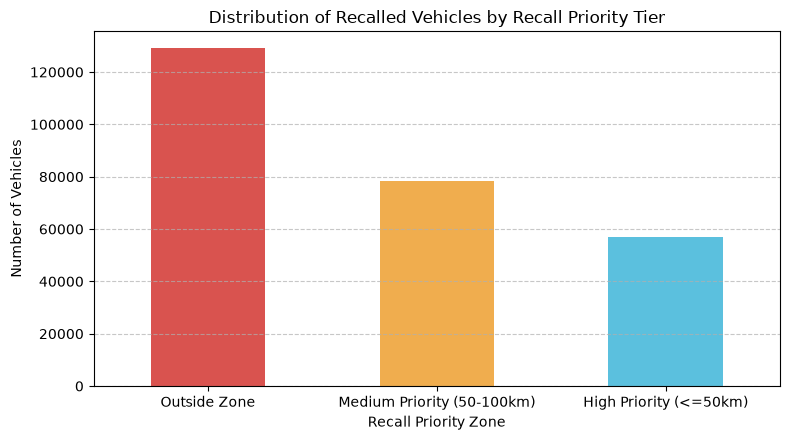

In [15]:
import matplotlib.pyplot as plt

# Plot distribution of recalled vehicles across priority tiers using standard Pandas method
priority_counts = df_recalled_geo['Recall_Priority'].value_counts()

plt.figure(figsize=(8, 4.5))
priority_counts.plot(kind='bar', color=['#d9534f', '#f0ad4e', '#5bc0de'])

plt.title("Distribution of Recalled Vehicles by Recall Priority Tier")
plt.xlabel("Recall Priority Zone")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 2.10 Exporting Final Processed Dataset for Downstream Analysis & Web Application
We export our consolidated, feature-enriched dataset containing all engine recall flags, registration parameters, municipality coordinates, and Haversine distance metrics to `SoSe26_Case_Study_finalData_Group_34.csv`. This satisfies Issue #5 and provides the required baseline table for downstream EDA reporting and Streamlit application integration.

In [36]:
# Export the complete processed dataset to CSV with semicolon separator
output_filename = "SoSe26_Case_Study_finalData_Group_34.csv"
df_recalled_geo.to_csv(output_filename, sep=';', index=False)

print("=== FINAL DATASET EXPORT SUCCESSFUL ===")
print(f"Saved file: {output_filename}")
print(f"Total Rows Exported: {len(df_recalled_geo)}")
print(f"Total Columns Exported: {len(df_recalled_geo.columns)}")

=== FINAL DATASET EXPORT SUCCESSFUL ===
Saved file: SoSe26_Case_Study_finalData_Group_34.csv
Total Rows Exported: 264476
Total Columns Exported: 28
